In [2]:
import os 

os.chdir("/Users/seungyeon/workspace/chord_recog/code/scripts")

In [3]:
from extractor.audio_extractor import AudioExtractor 
from extractor.feature_extractor import FeatureExtractor


# TEST_URL = "https://youtu.be/xKT92YmzhJw"
# TEST_URL = "https://youtu.be/T4lJNIH-iAg"
# TEST_URL = "https://youtu.be/T2ZaUFDOikU"
extractor = FeatureExtractor()
# audio_file = AudioExtractor().execute(TEST_URL)
audio_file = "/Users/seungyeon/workspace/chord_recog/code/scripts/Crush (크러쉬) - 'UP ALL NITE (Feat. SUMIN)' MV.wav"
# audio_file = "/Users/seungyeon/workspace/chord_recog/code/scripts/Crush, Han Sang Won - SKIP [AUDIO⧸MP3].wav"
# audio_file = "/Users/seungyeon/workspace/chord_recog/code/scripts/2-5-1.wav"
# if audio_file is not None:
#     beats, beats_t, cqt, chroma = FeatureExtractor().execute(str(audio_file))
#     os.remove(audio_file)

In [14]:
import librosa

sr = 22050
hop_length = 512 
fmin = librosa.note_to_hz("C3")

y, _ = librosa.load(audio_file, sr=sr)
y_harmonic, y_percussive = librosa.effects.hpss(y, margin=1.0)
y_bass_only = extractor.apply_lowpass_filter(y_harmonic, sr=sr, cutoff_freq=int(fmin))

In [4]:
import numpy as np

fmin = librosa.note_to_hz("C1")
hop_length = 512
n_bins = 36

C = np.abs(
    librosa.cqt(
        y_harmonic,
        sr=sr,
        hop_length=hop_length,
        fmin=fmin,
        n_bins=n_bins,
        bins_per_octave=12,
    )
)  # Shape: (36, N_frames)
# 곡의 미세 조율 상태를 센트(Cents) 단위로 추정 (예: +15cents 샵되어 있음 등)
estimated_tuning = librosa.estimate_tuning(y=y_harmonic, sr=sr)

# C3(약 130Hz) 미만의 저음역대를 크로마 계산에서 완전히 배제
# 저음역 베이스 악기의 5배음(E) 유출을 물리적으로 컷오프하는 대역 설정
fmin_chord = librosa.note_to_hz('C1')  # 약 130.8Hz

# C3부터 시작해서 상위 5옥타브(C8 영역까지)만 타겟팅
# 실제 피아노/EP의 코드 컴핑(Chording) 레지스터만 집중 분석
n_octaves_chord = 7

chroma_raw = librosa.feature.chroma_cqt(
    y=y_harmonic,
    sr=sr, 
    hop_length=hop_length,
    tuning=estimated_tuning,                         # 이전 단계에서 성공한 조율 보정
    bins_per_octave=36,                              # 3배수 고해상도 격자 유지
    fmin=fmin_chord,                                 # 최저 주파수 제한 (핵심)
    n_octaves=n_octaves_chord                        # 분석할 옥타브 범위 제한
)
# chroma_raw = librosa.feature.chroma_stft(
#     y=y_harmonic, 
#     sr=sr, 
#     hop_length=hop_length,
#     tuning=estimated_tuning,                         # 이전 단계에서 성공한 조율 보정
# )

In [15]:
import soundfile 

soundfile.write("/Users/seungyeon/workspace/chord_recog/code/scripts/bass_test.wav", y_bass_only, 22050)

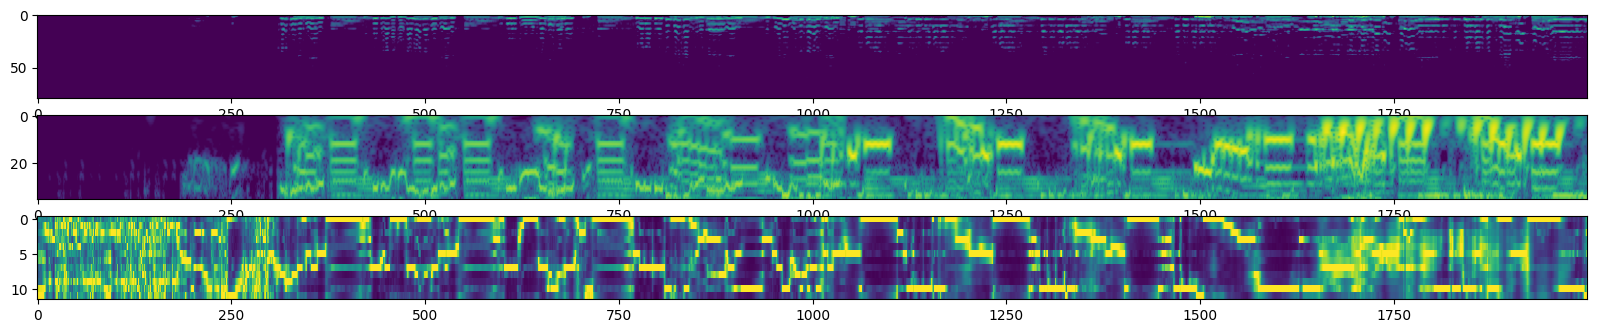

In [6]:
import matplotlib.pyplot as plt 


mel = librosa.feature.melspectrogram(y=y_harmonic, sr=sr, n_mels=80) 
mel = librosa.amplitude_to_db(mel)
# onsets_ = [o for o in onsets if o < 2000]

plt.figure(figsize=(20, 5))
plt.subplot(411)
plt.imshow(mel[:, :2000], aspect='auto')
# plt.vlines(onsets_, ymin=-0.5, ymax=19.5, colors="r")
plt.subplot(412)
plt.imshow(librosa.amplitude_to_db(C)[:, :2000], aspect='auto')
# plt.vlines(onsets_, ymin=-0.5, ymax=11.5, colors="r")
plt.subplot(413)
plt.imshow(chroma_raw[:, :2000], aspect='auto', interpolation='none')
# plt.plot(range(2000), bass_pitch[:2000])
# plt.vlines(onsets_, ymin=0, ymax=1, colors="r")
# plt.xlim([0, 2000])
# plt.subplot(414)
# plt.plot(range(2000), o_env_bass[:2000])
# plt.vlines(onsets_, ymin=0, ymax=1, colors="r")
# plt.xlim([0, 2000])
plt.show()

In [4]:
import librosa 


sr = 22050
hop_len = 512 

if audio_file is not None:
    y, _ = librosa.load(audio_file, sr=sr)
    beats_t = extractor.extract_beat(audio_file, len(y))

In [5]:
import os 
os.chdir("/Users/seungyeon/workspace/chord_recog/code/scripts")

import librosa 
from extractor.feature_extractor import FeatureExtractor

self = FeatureExtractor()

audio_path = "/Users/seungyeon/workspace/chord_recog/code/scripts/Crush (크러쉬) - 'UP ALL NITE (Feat. SUMIN)' MV.wav"
# audio_path = "/Users/seungyeon/workspace/chord_recog/code/scripts/2-5-1.wav"
y, _ = librosa.load(audio_path, sr=self.sr)

beats = self.extract_beat(audio_path, sample_size=len(y))
y_harmonic, _ = librosa.effects.hpss(y, margin=2.0)

In [6]:
bass_pitch, grid_times = self.extract_bass(y_harmonic, beats)
chroma_raw = self.extract_grid_synchronous_chroma(
    y_harmonic, grid_times, sr=self.sr, hop_length=self.hop_len
)
# chroma = self.suppress_bass_harmonics_on_chroma(chroma_raw, bass_pitch)

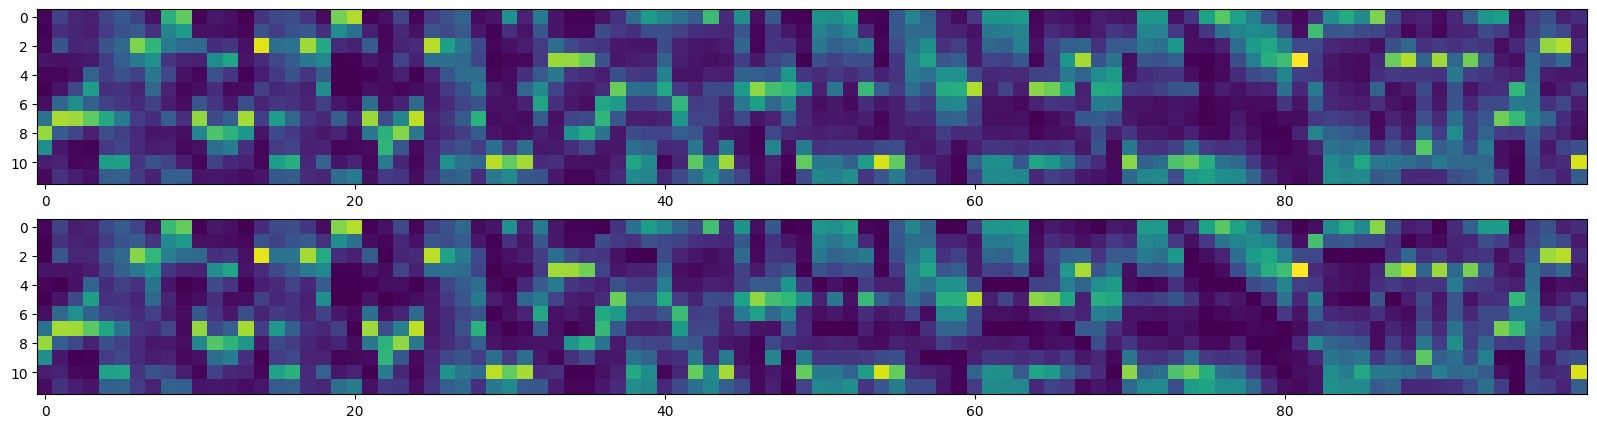

In [4]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(20, 5))
plt.subplot(211)
plt.imshow(chroma_raw[:, :100], aspect='auto', interpolation='none')
plt.subplot(212)
plt.imshow(chroma[:, :100], aspect='auto', interpolation='none')
plt.show()

In [7]:
from chord.constants import IDX_TO_PITCH_CLASS
from pretty_midi import PrettyMIDI, Note, Instrument


label = []
obj = PrettyMIDI()
obj.instruments.append(Instrument(0))
notes = []
for (start, end), b in zip(grid_times, bass_pitch):
    notes.append(Note(velocity=70, pitch=int(b), start=start, end=end))
obj.instruments[0].notes = notes 

obj.write("bass_test.mid")
    

In [7]:
with open("bass_test.lab", "w") as f:
    f.writelines(label)

In [1]:
import os 
os.chdir("/Users/seungyeon/workspace/chord_recog/code/scripts")

import numpy as np

from chord.converter import ChordConverter


converter = ChordConverter()
prob_matrix = converter.save_transition_matrix(
    "/Users/seungyeon/workspace/chord_recog/data/choco/jams"
)
np.save(
    "/Users/seungyeon/workspace/chord_recog/code/scripts/chord/transition_matrix.npy",
    prob_matrix,
    allow_pickle=True,
)
# count_matrix = compute_chord_transition_matrix_numpy(sequences, return_count=True)
# export_debug_pivot_table(count_matrix)

## End-to-end execution

In [1]:
import os 
os.chdir("/Users/seungyeon/workspace/chord_recog/code/scripts")

from extractor.feature_extractor import FeatureExtractor
from model.chord_recognizer import ChordRecognizer 

import time

# TEST_URL = "https://youtu.be/xKT92YmzhJw"
# TEST_URL = "https://youtu.be/T4lJNIH-iAg"

audio_file = "/Users/seungyeon/workspace/chord_recog/code/scripts/Crush (크러쉬) - 'UP ALL NITE (Feat. SUMIN)' MV.wav"
# audio_file = "/Users/seungyeon/workspace/chord_recog/code/scripts/Crush, Han Sang Won - SKIP [AUDIO⧸MP3].wav"
# audio_file = "/Users/seungyeon/workspace/chord_recog/code/scripts/2-5-1.wav"

print("Extracting features...")
start_time = time.time()
extractor = FeatureExtractor()
beats, bass_pitch, chroma = extractor.execute(audio_file)
print(f"Finished extraction -> {time.time() - start_time} secs")


Extracting features...
📊 오디오 특징(Chroma & Beat) 분석 중...
Finished extraction -> 20.20340085029602 secs


In [2]:
print("Extracting chords...")  
start_time = time.time()  
model = ChordRecognizer()
candidates = model.execute(chroma, bass_pitch)
print(f"Finished extraction -> {time.time() - start_time} secs")

Extracting chords...
Finished extraction -> 1.4883100986480713 secs


In [3]:
candidates[:, :100]

array([['C:dominant-seventh/C#', 'F:major', 'C:major', 'C:major',
        'C:major', 'C:major', 'C:major', 'C:major', 'F:major', 'C:major',
        'C:major', 'C:major', 'C:major', 'G:minor-seventh',
        'C:dominant-seventh', 'C:dominant-seventh', 'C:dominant-seventh',
        'C:dominant-seventh', 'C:dominant-seventh', 'F:minor-seventh',
        'F:minor-seventh/D#', 'A#:dominant-seventh',
        'A#:dominant-seventh', 'D#:minor-seventh', 'G#:dominant-seventh',
        'G:minor-seventh', 'C:dominant-seventh', 'A#:major-seventh',
        'C:dominant-seventh', 'C:dominant-seventh', 'G:minor-seventh',
        'C:dominant-seventh', 'F:major-seventh', 'F:major-seventh',
        'C:major-seventh', 'C:major-seventh', 'D:dominant-seventh',
        'D:dominant-seventh', 'C:major-seventh', 'C:major-seventh',
        'C:major-seventh', 'C:major-seventh', 'C:major-seventh',
        'D:dominant-seventh', 'G#:major-seventh', 'A#:dominant-seventh',
        'A#:dominant-seventh', 'A#:dominant-se

In [4]:
for n in range(candidates.shape[1]):
    cands = candidates[:, n]
    if len(set(cands)) != 1:
        print(n, cands)

0 ['G#:major-seventh/A' 'G#:major-seventh/C' 'G#:major-seventh/C']
290 ['A#:dominant-seventh' 'A#:minor' 'A#:dominant-seventh']
291 ['A#:dominant-seventh' 'A#:minor' 'A#:dominant-seventh']
292 ['G#:major-seventh' 'G#:major' 'G#:major-seventh']
293 ['G#:major-seventh' 'D#:major/G' 'G:minor-seventh']


In [3]:
lines = []
for (start, end), chord in zip(beats, candidates[0]):
    lines.append("\t".join([str(start), str(end), chord]) + "\n")

with open("chord_result_test.lab", "w") as f:
    f.writelines(lines)

In [1]:
import os 
os.chdir("/Users/seungyeon/workspace/chord_recog/code/scripts")

from chord.hpcp import generate_hpcp_chord_templates
from chord.converter import ChordConverter
import matplotlib.pyplot as plt 

TRANS_MATRIX = generate_hpcp_chord_templates()
idx1 = ChordConverter.encode_chord_from_state("C", "dominant-seventh")
idx2 = ChordConverter.encode_chord_from_state("C", "major-seventh")
idx3 = ChordConverter.encode_chord_from_state("C", "minor-seventh")
matrix = TRANS_MATRIX[[idx1, idx2, idx3]]

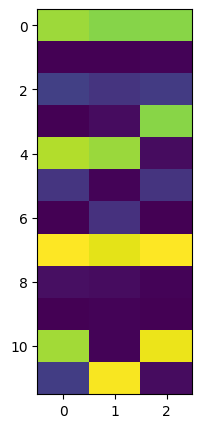

In [2]:
plt.figure(figsize=(2, 5))
plt.imshow(matrix.T, aspect='auto')
plt.show()

In [3]:
matrix[2]

array([0.51487421, 0.00061884, 0.11089598, 0.06435928, 0.01980285,
       0.10297484, 0.        , 0.60646241, 0.00544578, 0.        ,
       0.58245145, 0.01980285])